In [2]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import os
import pickle

In [3]:
def calcular_parametros(sim_data):
    u_hist = sim_data['u_history']
    X = sim_data['X_star']
    Y = sim_data['Y_star']

    final_u = u_hist[-1]

    # Tomamos la línea más baja (y≈0)
    y_line_idx = 1  # la segunda fila desde abajo
    u_bottom = final_u[y_line_idx, :]
    x_vals = X[y_line_idx, :]

    # Buscar cambio de signo de positivo a negativo (indica separación)
    signo = np.sign(u_bottom)
    cambios = np.where(np.diff(signo) < 0)[0]

    x_sep = None
    if len(cambios) > 0:
        x_sep = x_vals[cambios[0]]
    
    # Buscar burbuja de recirculación (donde u < 0)
    indices_negativos = np.where(u_bottom < 0)[0]
    bubble = None
    if len(indices_negativos) > 1:
        bubble = x_vals[indices_negativos[-1]] - x_vals[indices_negativos[0]]

    # Calcular delta como grosor de la capa límite al final
    y_vals = Y[:, -1]  # columna más a la derecha
    u_profile = final_u[:, -1]
    u_inf = np.max(u_profile)
    delta = None
    for i in range(len(u_profile)):
        if u_profile[i] >= 0.99 * u_inf:
            delta = y_vals[i]
            break

    return x_sep, bubble, delta


In [4]:
# Asegúrate de que calcular_parametros está definida antes de este bloque

# --- Configuración ---
carpeta = 'sim_separacion'
resoluciones = [25, 50, 100, 200, 400, 800]

# --- Resultados del análisis ---
resultados = []

def cargar_datos(resolucion):
    nombre_archivo = os.path.join(carpeta, f"{resolucion}x{resolucion}.pkl")
    with open(nombre_archivo, 'rb') as f:
        data = pickle.load(f)
    return data

# --- Carga y análisis de datos ---
for res in resoluciones:
    try:
        datos = cargar_datos(res)
        x_sep, bubble, delta = calcular_parametros(datos)
        resultados.append({
            'resolucion': res,
            'x_sep': x_sep,
            'bubble_size': bubble,
            'delta': delta
        })
    except Exception as e:
        print(f"❌ Error al procesar resolución {res}: {e}")

# --- Mostrar resultados individuales ---
for r in resultados:
    print(f"{r['resolucion']}x{r['resolucion']} -> "
          f"x_sep: {r['x_sep']}, bubble: {r['bubble_size']}, delta: {r['delta']}")

# --- Variables para análisis de convergencia ---
resoluciones_validas = [r['resolucion'] for r in resultados if r['delta'] is not None]
x_sep_vals = [r['x_sep'] for r in resultados if r['x_sep'] is not None]
bubble_vals = [r['bubble_size'] for r in resultados if r['bubble_size'] is not None]
delta_vals = [r['delta'] for r in resultados if r['delta'] is not None]


25x25 -> x_sep: 0.125, bubble: 0.8333333333333334, delta: 1.0
50x50 -> x_sep: 0.08163265306122448, bubble: 0.8979591836734694, delta: 1.0
100x100 -> x_sep: 0.04040404040404041, bubble: 0.9494949494949495, delta: 1.0
200x200 -> x_sep: 0.020100502512562814, bubble: 0.9748743718592965, delta: 1.0
400x400 -> x_sep: 0.010025062656641603, bubble: 0.987468671679198, delta: 1.0
800x800 -> x_sep: 0.0050062578222778474, bubble: 0.9937421777221527, delta: 0.9987484355444306


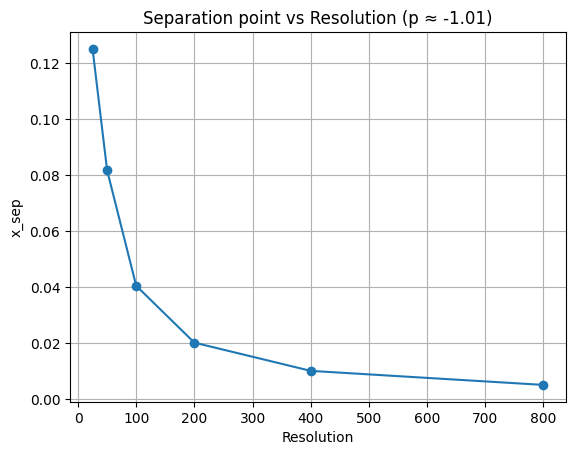

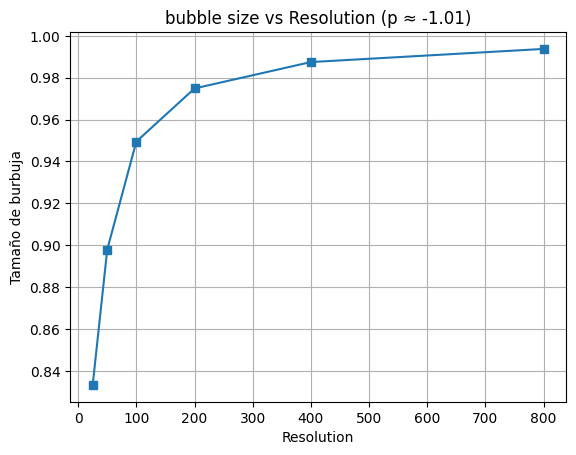

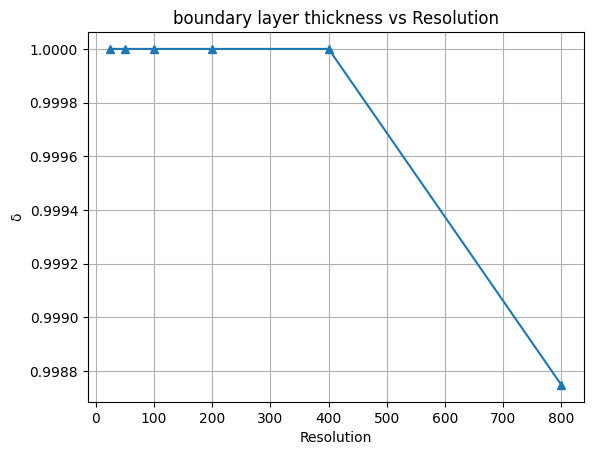

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Datos obtenidos
resoluciones = [25, 50, 100, 200, 400, 800]

# Función para calcular orden de convergencia
def orden_convergencia(f1, f2, f3, r):
    return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

# Calcular orden de convergencia (solo con los 3 valores más refinados)
r = 2
p_xsep = orden_convergencia(x_sep_vals[2], x_sep_vals[3], x_sep_vals[4], r)
p_bubble = orden_convergencia(bubble_vals[2], bubble_vals[3], bubble_vals[4], r)

# delta es casi constante; su orden no es confiable
delta_casi_constante = all(np.isclose(d, 1.0) for d in delta_vals[:-1])
p_delta = None if delta_casi_constante else orden_convergencia(delta_vals[2], delta_vals[3], delta_vals[4], r)

# Gráfica para x_sep
plt.figure()
plt.plot(resoluciones, x_sep_vals, marker='o')
plt.title(f'Separation point vs Resolution (p ≈ {p_xsep:.2f})')
plt.xlabel('Resolution')
plt.ylabel('x_sep')
plt.grid()

# Gráfica para tamaño de burbuja
plt.figure()
plt.plot(resoluciones, bubble_vals, marker='s')
plt.title(f'bubble size vs Resolution (p ≈ {p_bubble:.2f})')
plt.xlabel('Resolution')
plt.ylabel('Tamaño de burbuja')
plt.grid()

# Gráfica para delta
plt.figure()
plt.plot(resoluciones, delta_vals, marker='^')
title = 'boundary layer thickness vs Resolution'
if p_delta is not None:
    title += f' (p ≈ {p_delta:.2f})'
plt.title(title)
plt.xlabel('Resolution')
plt.ylabel('δ')
plt.grid()

plt.show()


# DATA ASSIMILATION

In [49]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation,FFMpegWriter
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd

@njit(parallel=True, fastmath=True)
def actualizar_campos(presion_adversa, u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):
    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] +
                                       p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)
    
    # Gradiente de presión controlado
    for j in prange(nx):
        x = j * dx_star
        for i in prange(ny):
            if x <= 0.3:
                p_star[i, j] += 0.01  # presión constante en entrada
            else:
                p_star[i, j] += presion_adversa * (x - 0.3)


    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y +
                                       (1 / (Re * Pr)) * (diff_T_x + diff_T_y) +
                                       viscous_heating)

    tau = np.zeros((ny, nx))
    for i in prange(1, ny - 1):
        for j in prange(nx):
            tau[i, j] = (u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star)

# Condiciones de frontera
    v_star[0, :] = 0
    v_star[-1, :] = 0
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    u_star[:, -1] = u_star[:, -2]
    p_star[:, 0] = p_star[:, 1]
    p_star[:, -1] = p_star[:, -2]
    p_star[0, :] = p_star[1, :]
    p_star[-1, :] = p_star[-2, :]

    return u_star, v_star, p_star, T_star, tau

def extraer_observaciones(N_sens=10, T_sens=5, size=800, carpeta="sim_separacion", ruido_std=0.0, seed=None):
    import numpy as np
    import os
    import pickle

    if seed is not None:
        np.random.seed(seed)

    path = os.path.join(carpeta, f"{size}x{size}.pkl")
    with open(path, "rb") as f:
        datos = pickle.load(f)

    T_hist = datos["T_history"]
    p_hist = datos["p_history"]
    tau_hist = datos["tau_history"]

    nt = len(T_hist)
    y_idx = 0  # y=0 línea inferior
    x_physical = np.linspace(0, 1, N_sens)

    observaciones = []
    frame_indices = np.linspace(0, nt - 1, T_sens, dtype=int)

    for t in frame_indices:
        T_line = T_hist[t][y_idx, :]
        p_line = p_hist[t][y_idx, :]
        tau_line = tau_hist[t][y_idx, :]
        nx = T_line.shape[0]

        x_idx_fine = (x_physical * (nx - 1)).astype(int)

        obs_t = {
            "t": t,
            "x_phys": x_physical,
            "T": T_line[x_idx_fine].copy(),
            "p": p_line[x_idx_fine].copy(),
            "tau": tau_line[x_idx_fine].copy()
        }

        if ruido_std > 0.0:
            obs_t["T"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["p"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["tau"] += np.random.normal(0, ruido_std, size=N_sens)

        observaciones.append(obs_t)

    return observaciones


def calcular_rmse(campo_estimado, campo_referencia):
    """
    Calcula el RMSE medio por frame entre dos listas de campos (e.g. T).
    """
    errores = []
    for c_est, c_ref in zip(campo_estimado, campo_referencia):
        err = np.sqrt(np.mean((c_est - c_ref)**2))
        errores.append(err)
    return np.array(errores)


def comparar_resultados(resultados_base, resultados_dict, resultados_ref, variable='T'):
    """
    Compara el RMSE temporal entre una simulación base y múltiples métodos de asimilación.

    Parámetros:
    - resultados_base: dict con historial sin asimilación
    - resultados_dict: dict de resultados con asimilación {nombre_metodo: resultados}
    - resultados_ref: dict de referencia (ground truth)
    - variable: 'T', 'p', 'tau', etc.
    """
    var_map = {
        'T': 'T_history',
        'p': 'p_history',
        'u': 'u_history',
        'v': 'v_history',
        'tau': 'tau_history'
    }
    var_key = var_map[variable]

    # Historial de la base y la referencia
    hist_base = resultados_base[var_key]
    hist_ref = resultados_ref[var_key]

    # Calcular RMSE para cada método
    plt.figure(figsize=(10, 5))
    rmse_base = calcular_rmse(hist_base, hist_ref)
    plt.plot(rmse_base, label='Sin asimilación', linestyle='--')

    for nombre_metodo, resultados in resultados_dict.items():
        if var_key not in resultados:
            print(f"⚠️  {nombre_metodo} no contiene la variable '{variable}'")
            continue
        hist_asim = resultados[var_key]
        rmse_asim = calcular_rmse(hist_asim, hist_ref)
        plt.plot(rmse_asim, label=nombre_metodo)

    plt.title(f"RMSE temporal para {variable}")
    plt.xlabel("Timestep")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def animar_comparacion(base_data, asim_data, ref_data, variable='T'):
    """
    Animación con:
    [0] Simulación sin asimilación
    [1] Simulación con asimilación
    [2] Error absoluto entre asimilación y referencia

    Solo se muestra el título general con la magnitud y el instante de tiempo.
    """
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation

    # Mapeo de clave a historial
    var_map = {
        'T': 'T_history',
        'p': 'p_history',
        'u': 'u_history',
        'v': 'v_history',
        'tau': 'tau_history'
    }

    nombres = {
        'T': 'Temperatura',
        'p': 'Presión',
        'u': 'Velocidad u',
        'v': 'Velocidad v',
        'tau': 'Esfuerzo cortante'
    }

    assert variable in var_map, f"Variable '{variable}' no válida"
    var_key = var_map[variable]
    nombre_var = nombres.get(variable, variable)

    X = base_data["X_star"]
    Y = base_data["Y_star"]
    base_hist = base_data[var_key]
    asim_hist = asim_data[var_key]
    ref_hist = ref_data[var_key]

    nframes = min(len(base_hist), len(asim_hist), len(ref_hist))
    dt_star = base_data["params"]["dt_star"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
    titles = [
        "Sin Asimilación",
        "Con Asimilación",
        "Error Abs. (Asimilado - Verdad)"
    ]
    cmaps = ['jet', 'jet', 'hot']
    colorbars = [None] * 3

    def plot_frame(frame_idx):
        datasets = [
            base_hist[frame_idx],
            asim_hist[frame_idx],
            np.abs(asim_hist[frame_idx] - ref_hist[frame_idx])
        ]

        for i, (ax, title, cmap, data) in enumerate(zip(axs, titles, cmaps, datasets)):
            ax.clear()
            cf = ax.contourf(X, Y, data, levels=20, cmap=cmap)
            ax.set_title(title)
            ax.set_xlabel("x*")
            ax.set_ylabel("y*")
            if colorbars[i] is None:
                colorbars[i] = plt.colorbar(cf, ax=ax)

    def update(frame):
        plot_frame(frame)
        fig.suptitle(
            f"Comparación de {nombre_var} ({variable}*) | t* = {frame / (nframes - 1):.2f}",
            fontsize=16
        )
        return axs

    plot_frame(0)
    fig.suptitle(f"Comparación de {nombre_var} ({variable}*)", fontsize=16)
    anim = FuncAnimation(fig, update, frames=nframes, interval=150, blit=False)
    plt.tight_layout()
    return anim, fig



def interpolar_historial(hist_ref, X_ref, Y_ref, X_dest, Y_dest):
    """
    Interpola una lista de campos 2D desde una malla de alta resolución (X_ref, Y_ref)
    a una malla objetivo (X_dest, Y_dest).
    """
    ny_ref, nx_ref = X_ref.shape
    ny_dest, nx_dest = X_dest.shape

    x_ref = np.linspace(0, 1, nx_ref)
    y_ref = np.linspace(0, 1, ny_ref)

    x_dest = np.linspace(0, 1, nx_dest)
    y_dest = np.linspace(0, 1, ny_dest)
    Xq, Yq = np.meshgrid(x_dest, y_dest)
    puntos_destino = np.stack([Yq.ravel(), Xq.ravel()], axis=-1)

    historial_interp = []
    for campo in hist_ref:
        interpolador = RegularGridInterpolator((y_ref, x_ref), campo)
        campo_interp = interpolador(puntos_destino).reshape(ny_dest, nx_dest)
        historial_interp.append(campo_interp)

    return historial_interp

def interpolar_resultados_completos(resultados_ref, resultados_destino):
    """
    Interpola todos los campos de resultados_ref a la malla de resultados_destino.
    Devuelve un nuevo diccionario 'resultados_ref_interp' con T, p, u, v, tau adaptados.
    """
    campos = ['T_history', 'p_history', 'u_history', 'v_history', 'tau_history']
    X_ref = resultados_ref['X_star']
    Y_ref = resultados_ref['Y_star']
    X_dest = resultados_destino['X_star']
    Y_dest = resultados_destino['Y_star']

    resultados_ref_interp = resultados_ref.copy()
    for campo in campos:
        resultados_ref_interp[campo] = interpolar_historial(
            resultados_ref[campo], X_ref, Y_ref, X_dest, Y_dest
        )

    # ✅ Mallas de destino (para evitar errores de shape en animaciones)
    resultados_ref_interp["X_star"] = X_dest
    resultados_ref_interp["Y_star"] = Y_dest


    return resultados_ref_interp

def comparar_lineas_corriente(resultados_dict, resultados_base, resultados_ref, y_linea=0.05):
    """
    Dibuja la línea de corriente que contiene a la burbuja de separación
    para cada método (incluyendo sin asimilación y referencia).
    """
    plt.figure(figsize=(10, 5))
    y_idx = int(y_linea * resultados_base['ny'])  # índice aproximado en y

    todos = {'Sin Asimilación': resultados_base, **resultados_dict, 'Referencia': resultados_ref}
    colores = ['k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'gray']
    linestyles = ['--', '-', '-', '-', '-', ':']

    for (nombre, datos), color, ls in zip(todos.items(), colores, linestyles):
        X = datos["X_star"]
        Y = datos["Y_star"]
        u = datos["u_history"][-1]
        v = datos["v_history"][-1]

        # Línea de corriente por seed en la base
        start_x = np.linspace(0.05, 0.95, 8)
        start_y = np.ones_like(start_x) * y_linea

        plt.streamplot(X[0], Y[:, 0], u, v, color=color, linewidth=1.2,
                       start_points=np.column_stack([start_x, start_y]),
                       integration_direction='forward',
                       density=1.2,
                       arrowsize=1,
                       linestyle=ls,
                       label=nombre)

    plt.title("Líneas de corriente cerca de la pared inferior")
    plt.xlabel("x*")
    plt.ylabel("y*")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def mostrar_tiempos_asimilacion(resultados_dict):
    """
    Imprime los tiempos de asimilación registrados por cada método.
    """
    print("⏱️  Tiempos de asimilación por método:")
    for nombre, resultados in resultados_dict.items():
        tiempo = resultados.get("asimilacion_time", None)
        if tiempo is not None:
            print(f"   - {nombre:10s}: {tiempo:.2f} segundos")
        else:
            print(f"   - {nombre:10s}: (no registrado)")


# ========================NUDGING========================

def run_nudging(nx=25, ny=25, guardar_en_disco=False, folder='sim_nudging',
                presion_adversa=0.3, observaciones_dict=None,
                variables_asimilar=['T'], alpha=0.3):

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u0, up = 1.0, -1.0
    T0_star, T1_star = 0.0, 0.0
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.ones((ny, nx)) * T1_star
    u_star[0, :] = up
    u_star[-1, :] = u0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    save_interval = max(1, nt // 300)
    frame_folder = None

    if guardar_en_disco:
        frame_folder = os.path.join(folder, f"{nx}x{ny}_frames")
        os.makedirs(frame_folder, exist_ok=True)

    total_nudging_time = 0.0  # antes del bucle

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        # Aplicar Nudging si hay observaciones en este paso
        if observaciones_dict is not None and n in observaciones_dict:
            t0 = time.time()
            obs_t = observaciones_dict[n]
            if 'T' in variables_asimilar:
                T_star = aplicar_nudging(T_star, obs_t, 'T', alpha, nx, ny)
            if 'p' in variables_asimilar:
                p_star = aplicar_nudging(p_star, obs_t, 'p', alpha, nx, ny)
            if 'tau' in variables_asimilar:
                tau = aplicar_nudging(tau, obs_t, 'tau', alpha, nx, ny)

            total_nudging_time += time.time() - t0

        if n % save_interval == 0 or n == nt - 1:
            print(f"\rPaso {n}/{nt}", end="")
            if guardar_en_disco:
                np.save(os.path.join(frame_folder, f"u_{n:05d}.npy"), u_star)
                np.save(os.path.join(frame_folder, f"v_{n:05d}.npy"), v_star)
                np.save(os.path.join(frame_folder, f"p_{n:05d}.npy"), p_star)
                np.save(os.path.join(frame_folder, f"T_{n:05d}.npy"), T_star)
                np.save(os.path.join(frame_folder, f"tau_{n:05d}.npy"), tau)
            else:
                u_hist.append(u_star.copy())
                v_hist.append(v_star.copy())
                p_hist.append(p_star.copy())
                T_hist.append(T_star.copy())
                tau_hist.append(tau.copy())

    print("\n✅ Simulación con nudging finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa, "nudging_alpha": alpha,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "frame_folder": frame_folder if guardar_en_disco else None,
        "asimilacion_time": total_nudging_time,
    }


def aplicar_nudging(campo_modelo, observaciones, variable, alpha, nx, ny):
    x_idx = (observaciones["x_phys"] * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # sensores están en y=0
    campo_obs = observaciones[variable]

    campo_actualizado = campo_modelo.copy()
    for xi, yi, obs_val in zip(x_idx, y_idx, campo_obs):
        campo_actualizado[yi, xi] += alpha * (obs_val - campo_modelo[yi, xi])

    return campo_actualizado

# =========================KALMAN FILTER================================

def run_kalman(nx=25, ny=25, guardar_en_disco=False, folder='sim_kalman',
               presion_adversa=0.3, observaciones_dict=None,
               variables_asimilar=['T'], alpha=0.3,
               sigma_obs=0.01, sigma_modelo=1e-4,
               seed=None):
    
    """
    Simulación con filtro de Kalman para asimilación de datos.
    variables_asimilar: lista con 'T', 'p', 'tau'
    sigma_obs: desviación estándar del ruido de observación
    sigma_modelo: varianza asumida del modelo
    """

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u_star = np.ones((ny, nx))
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx))
    tau = np.zeros((ny, nx))

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_kalman_time = 0.0

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        if observaciones_dict is not None and n in observaciones_dict:
            obs = observaciones_dict[n]
            t0 = time.time()

            for var in variables_asimilar:
                campo_modelo = {'T': T_star, 'p': p_star, 'tau': tau}[var]
                campo_corregido = aplicar_kalman_update(
                    campo_modelo,
                    observaciones=obs[var],
                    x_phys=obs["x_phys"],
                    nx=nx, ny=ny,
                    sigma_obs=sigma_obs,
                    sigma_modelo=sigma_modelo
                )
                if var == 'T':
                    T_star = campo_corregido
                elif var == 'p':
                    p_star = campo_corregido
                elif var == 'tau':
                    tau = campo_corregido

            total_kalman_time += time.time() - t0

        u_hist.append(u_star.copy())
        v_hist.append(v_star.copy())
        p_hist.append(p_star.copy())
        T_hist.append(T_star.copy())
        tau_hist.append(tau.copy())

    print("✅ Simulación con Kalman finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "kalman_sigma_obs": sigma_obs,
            "kalman_sigma_modelo": sigma_modelo,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_kalman_time,
    }


def aplicar_kalman_update(campo_modelo, observaciones, x_phys, nx, ny, sigma_obs, sigma_modelo):
    """
    Corrige el campo_modelo en y=0 con observaciones puntuales usando Kalman filter.
    """
    campo_corregido = campo_modelo.copy()
    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)

    # Matrices (reducidas al tamaño de sensores)
    H = np.eye(len(x_idx))         # observamos directamente las celdas
    R = np.eye(len(x_idx)) * sigma_obs**2
    P = np.eye(len(x_idx)) * sigma_modelo**2

    x_fondo = campo_modelo[y_idx, x_idx]
    y_obs = observaciones

    # Kalman gain
    K = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)

    # Actualización del estado
    x_actualizado = x_fondo + K @ (y_obs - H @ x_fondo)

    for xi, yi, val in zip(x_idx, y_idx, x_actualizado):
        campo_corregido[yi, xi] = val

    return campo_corregido

#=========================ENSEMBLE KALMAN FILTER========================

def run_enkf(nx=25, ny=25, N_ens=10, guardar_en_disco=False, folder='sim_enkf',
             presion_adversa=0.3, observaciones_dict=None,
             variables_asimilar=['T'], sigma_obs=0.01, sigma_modelo=1e-4,
             seed=None):

    from copy import deepcopy

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Inicialización del ensamble
    def crear_estado_inicial():
        u_star = np.ones((ny, nx)) * 1.0
        v_star = np.zeros((ny, nx))
        p_star = np.zeros((ny, nx))
        T_star = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))

        u_star[0, :] = -0.5
        u_star[-1, :] = 1.0
        T_star[0, :] = 0.0
        T_star[-1, :] = 0.0

        return u_star, v_star, p_star, T_star, tau

    ensamble = []
    for _ in range(N_ens):
        u, v, p, T, tau = crear_estado_inicial()
        ensamble.append({'u': u, 'v': v, 'p': p, 'T': T, 'tau': tau})

    # Historial de la media del ensamble
    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        for k in range(N_ens):
            u, v, p, T, tau = ensamble[k]['u'], ensamble[k]['v'], ensamble[k]['p'], ensamble[k]['T'], ensamble[k]['tau']
            u_new, v_new, p_new, T_new, tau_new = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            ensamble[k] = {'u': u_new, 'v': v_new, 'p': p_new, 'T': T_new, 'tau': tau_new}

        if observaciones_dict is not None and n in observaciones_dict:
            t0 = time.time()
            obs = observaciones_dict[n]

            for var in variables_asimilar:
                ensamble = aplicar_enkf_update(
                    ensamble=ensamble,
                    obs=obs,
                    var=var,
                    x_phys=obs['x_phys'],
                    nx=nx,
                    ny=ny,
                    sigma_obs=sigma_obs,
                    seed=seed + n if seed is not None else None  # reproducibilidad por paso
                )
            total_assim_time += time.time() - t0

        # Guardar promedio del ensamble
        u_hist.append(np.mean([m['u'] for m in ensamble], axis=0))
        v_hist.append(np.mean([m['v'] for m in ensamble], axis=0))
        p_hist.append(np.mean([m['p'] for m in ensamble], axis=0))
        T_hist.append(np.mean([m['T'] for m in ensamble], axis=0))
        tau_hist.append(np.mean([m['tau'] for m in ensamble], axis=0))

        if n % (nt // 20) == 0:
            print(f"\rPaso {n}/{nt}", end="")

    print("\n✅ Simulación con EnKF finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "N_ens": N_ens,
            "sigma_obs": sigma_obs,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }

def aplicar_enkf_update(ensamble, obs, var, x_phys, nx, ny, sigma_obs, seed=None):
    """
    Aplica actualización EnKF para una variable y observaciones en y=0.

    Parámetros:
    - ensamble: lista de dicts {'T', 'p', 'tau'}
    - obs: diccionario con valores observados
    - var: 'T', 'p' o 'tau'
    - x_phys: posiciones físicas de los sensores [0, 1]
    """
    N_ens = len(ensamble)
    N_obs = len(x_phys)

    if seed is not None:
        np.random.seed(seed)

    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)

    Y = np.zeros((N_obs, N_ens))
    for e, miembro in enumerate(ensamble):
        campo = miembro[var]
        Y[:, e] = campo[y_idx, x_idx]

    y_mean = np.mean(Y, axis=1, keepdims=True)
    X_prime = Y - y_mean

    D = np.tile(obs[var].reshape(-1, 1), (1, N_ens))
    D += np.random.normal(0, sigma_obs, size=D.shape)

    R = np.eye(N_obs) * sigma_obs**2
    P_yy = (X_prime @ X_prime.T) / (N_ens - 1) + R
    K = (X_prime @ X_prime.T.T) @ np.linalg.inv(P_yy)

    for e in range(N_ens):
        correction = K @ (D[:, e] - Y[:, e])
        for i, xi in enumerate(x_idx):
            yi = y_idx[i]
            ensamble[e][var][yi, xi] += correction[i]

    return ensamble


#========================4D-VAR========================

def run_4dvar(nx=25, ny=25, observaciones_dict=None,
              variables_asimilar=['T'], ventana=5, n_iter=10,
              alpha=1e-2, presion_adversa=0.3,
              seed=None):

    import copy

    if seed is not None:
        np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    def crear_estado_inicial():
        u_star = np.ones((ny, nx))
        v_star = np.zeros((ny, nx))
        p_star = np.zeros((ny, nx))
        T_star = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u_star[0, :] = -0.5
        u_star[-1, :] = 1.0
        return u_star, v_star, p_star, T_star, tau

    u0, v0, p0, T0, tau0 = crear_estado_inicial()
    T0_opt = T0.copy()

    for it in range(n_iter):
        T_trial = T0_opt.copy()
        u, v, p, T, tau = u0.copy(), v0.copy(), p0.copy(), T_trial, tau0.copy()
        J = 0.0
        for step in range(ventana):
            u, v, p, T, tau = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            t_global = step
            if observaciones_dict and t_global in observaciones_dict:
                obs = observaciones_dict[t_global]
                for var in variables_asimilar:
                    if var == 'T':
                        x_idx = (obs['x_phys'] * (nx - 1)).astype(int)
                        y_idx = np.zeros_like(x_idx)
                        modelo = T[y_idx, x_idx]
                        obs_vals = obs['T']
                        J += np.sum((modelo - obs_vals) ** 2)

        grad = (T0_opt - T0)
        T0_opt -= alpha * grad
        print(f"Iteración {it + 1}/{n_iter}, J={J:.4f}")

    u_star, v_star, p_star, T_star, tau_star = u0.copy(), v0.copy(), p0.copy(), T0_opt.copy(), tau0.copy()
    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    for n in range(nt):
        u_star, v_star, p_star, T_star, tau_star = actualizar_campos(
            presion_adversa, u_star, v_star, p_star, T_star,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )
        u_hist.append(u_star.copy())
        v_hist.append(v_star.copy())
        p_hist.append(p_star.copy())
        T_hist.append(T_star.copy())
        tau_hist.append(tau_star.copy())

    print("✅ Simulación 4D-Var finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "ventana": ventana,
            "n_iter": n_iter,
            "alpha": alpha,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star
    }



Paso 5999/6000
✅ Simulación con nudging finalizada.
Paso 5999/6000
✅ Simulación con nudging finalizada.
✅ Simulación con Kalman finalizada.
Paso 5700/6000
✅ Simulación con EnKF finalizada.
Iteración 1/10, J=10.0903
Iteración 2/10, J=10.0903
Iteración 3/10, J=10.0903
Iteración 4/10, J=10.0903
Iteración 5/10, J=10.0903
Iteración 6/10, J=10.0903
Iteración 7/10, J=10.0903
Iteración 8/10, J=10.0903
Iteración 9/10, J=10.0903
Iteración 10/10, J=10.0903
✅ Simulación 4D-Var finalizada.


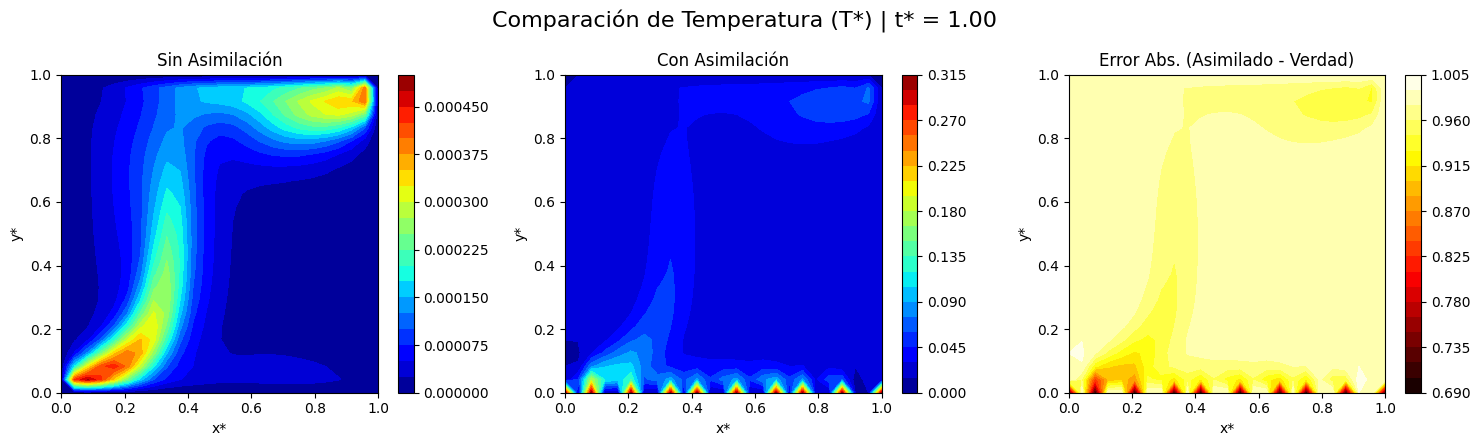

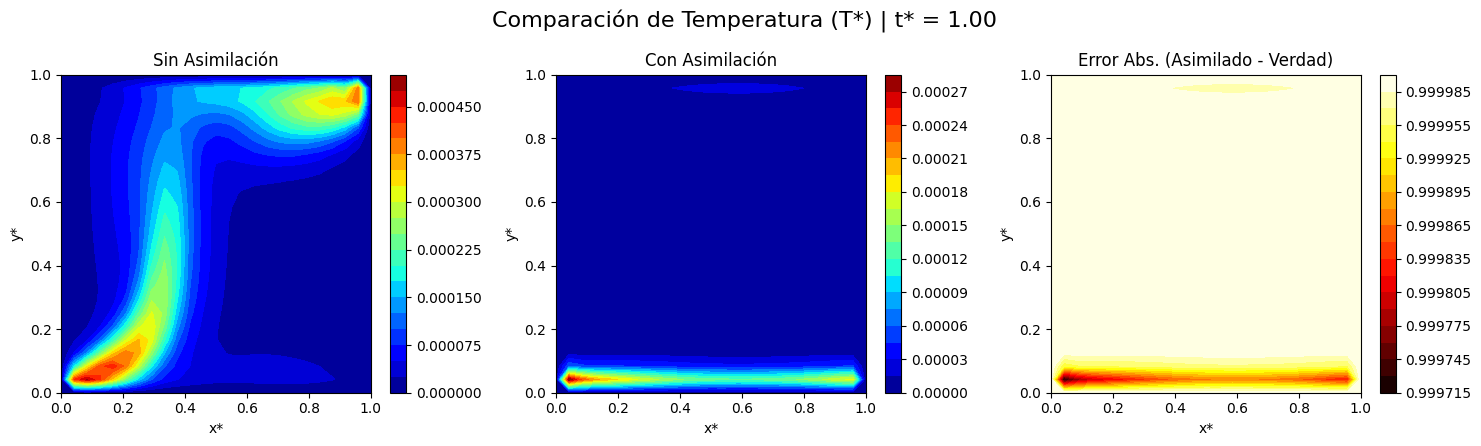

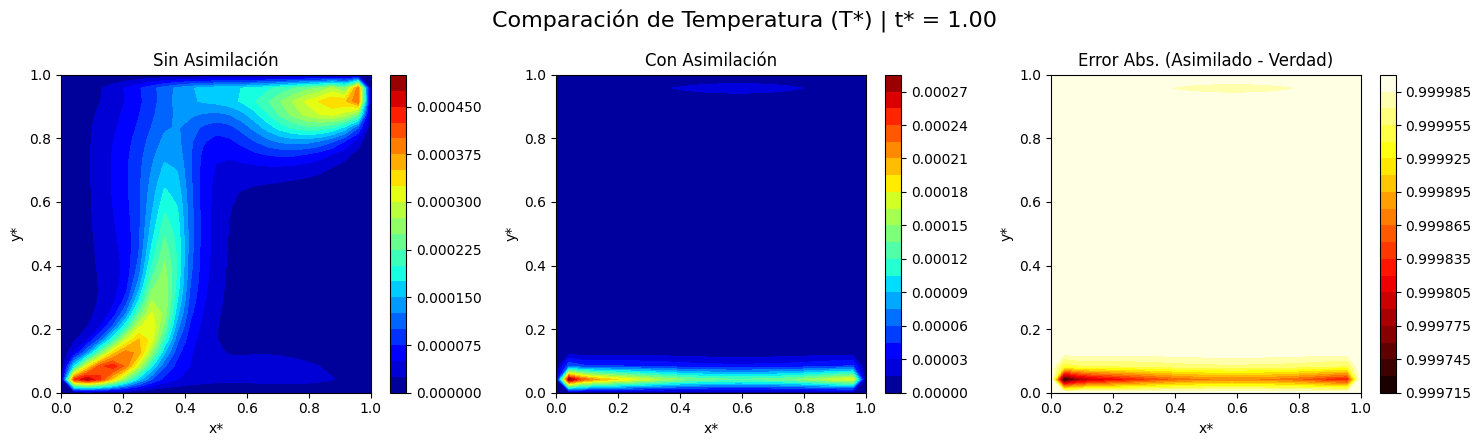

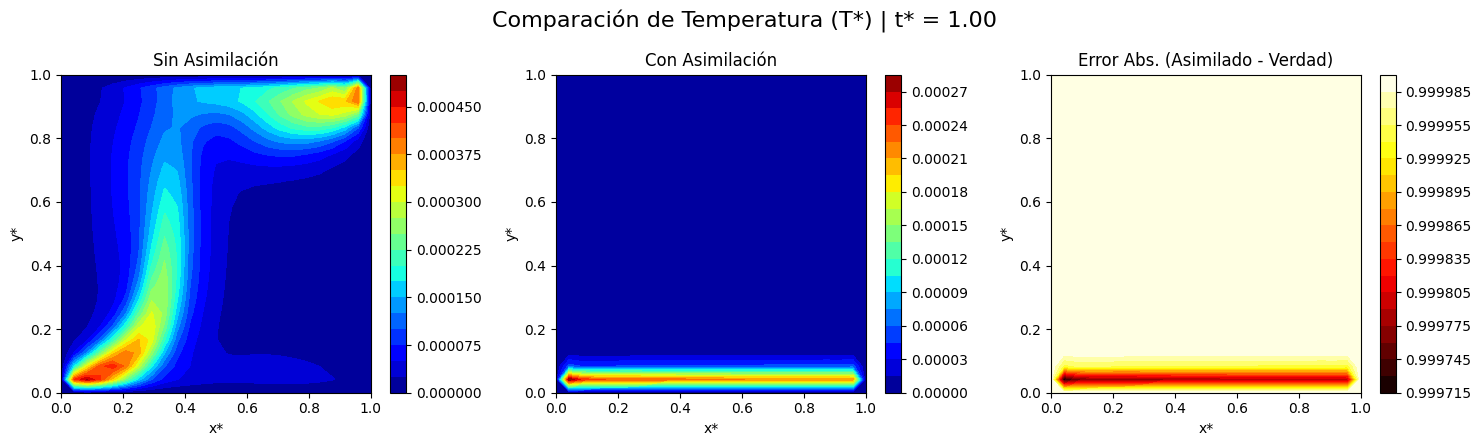

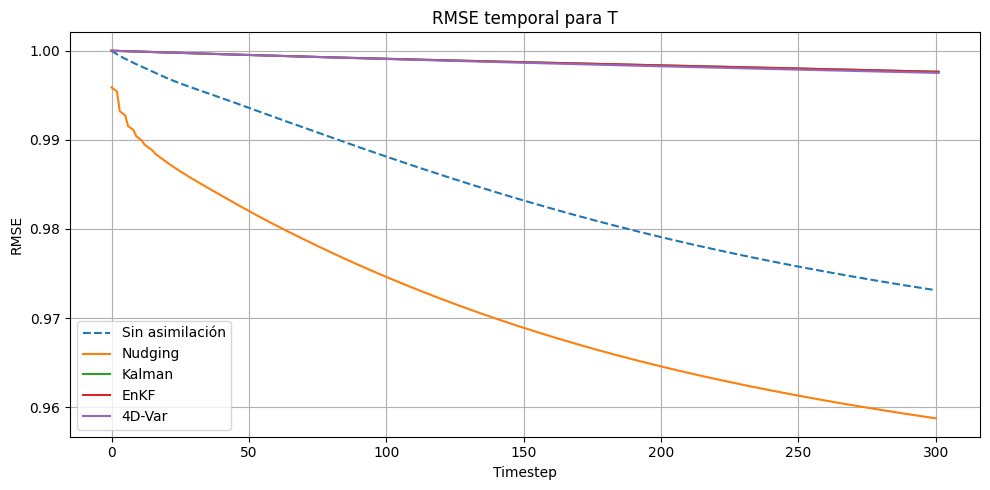

In [ ]:
# ------------------ PARÁMETROS GENERALES ------------------
size = 25
variable = 'T'
nombre_sim = f"{size}x{size}"
ruido_std = 0.01
N_sens = 10
T_sens = 6
np.random.seed(42)

# ------------------ PARÁMETROS POR MÉTODO ------------------
params = {
    "nudging": {"alpha": 0.3},
    "kf": {"sigma_obs": 0.01, "sigma_modelo": 1e-4},
    "enkf": {"N_ens": 10, "sigma_obs": 0.01, "sigma_modelo": 1e-4},
    "4dvar": {"ventana": 5, "n_iter": 10, "alpha": 1e-2}
}

# ------------------ RUTAS ------------------
output_dir = f"DA/{nombre_sim}_{variable}"
os.makedirs(output_dir, exist_ok=True)

rutas = {
    metodo: {
        "datos": os.path.join(output_dir, f"{metodo}_{nombre_sim}.pkl"),
        "video": os.path.join(output_dir, f"{metodo}_{nombre_sim}_{variable}.mp4")
    }
    for metodo in ["nudging", "kf", "enkf", "4dvar"]
}

# ------------------ CARGA Y OBSERVACIONES ------------------
with open("sim_separacion/800x800.pkl", "rb") as f:
    resultados_ref = pickle.load(f)

with open("sim_separacion/25x25.pkl", "rb") as g:
    resultados_base = pickle.load(g)

obs = extraer_observaciones(N_sens=N_sens, T_sens=T_sens, size=800, ruido_std=ruido_std)
obs_dict = {o["t"]: o for o in obs}

resultados_ref_interp = interpolar_resultados_completos(resultados_ref, resultados_base)

# ------------------ MÉTODOS DE ASIMILACIÓN ------------------
resultados_dict = {}

# NUDGING
res_nudging = run_nudging(
    nx=size, ny=size,
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    alpha=params["nudging"]["alpha"]
)
with open(rutas["nudging"]["datos"], "wb") as f:
    pickle.dump(res_nudging, f)
anim, _ = animar_comparacion(resultados_base, res_nudging, resultados_ref_interp, variable)
anim.save(rutas["nudging"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["Nudging"] = res_nudging

# KALMAN FILTER
res_kf = run_kalman(
    nx=size, ny=size,
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    sigma_obs=params["kf"]["sigma_obs"],
    sigma_modelo=params["kf"]["sigma_modelo"]
)
with open(rutas["kf"]["datos"], "wb") as f:
    pickle.dump(res_kf, f)
anim, _ = animar_comparacion(resultados_base, res_kf, resultados_ref_interp, variable)
anim.save(rutas["kf"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["Kalman"] = res_kf

# ENSEMBLE KALMAN FILTER
res_enkf = run_enkf(
    nx=size, ny=size,
    N_ens=params["enkf"]["N_ens"],
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    sigma_obs=params["enkf"]["sigma_obs"],
    sigma_modelo=params["enkf"]["sigma_modelo"]
)
with open(rutas["enkf"]["datos"], "wb") as f:
    pickle.dump(res_enkf, f)
anim, _ = animar_comparacion(resultados_base, res_enkf, resultados_ref_interp, variable)
anim.save(rutas["enkf"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["EnKF"] = res_enkf

# 4D-VAR
res_4dvar = run_4dvar(
    nx=size, ny=size,
    observaciones_dict=obs_dict,
    variables_asimilar=[variable],
    ventana=params["4dvar"]["ventana"],
    n_iter=params["4dvar"]["n_iter"],
    alpha=params["4dvar"]["alpha"]
)
with open(rutas["4dvar"]["datos"], "wb") as f:
    pickle.dump(res_4dvar, f)
anim, _ = animar_comparacion(resultados_base, res_4dvar, resultados_ref_interp, variable)
anim.save(rutas["4dvar"]["video"], writer=FFMpegWriter(fps=10))
resultados_dict["4D-Var"] = res_4dvar

# ------------------ COMPARACIÓN FINAL ------------------
comparar_resultados(resultados_base, resultados_dict, resultados_ref_interp, variable=variable)


In [50]:
# --- COMPARACIÓN DE LÍNEAS DE CORRIENTE ---
comparar_lineas_corriente(resultados_dict, resultados_base, resultados_ref_interp)

# --- TIEMPOS DE ASIMILACIÓN ---
mostrar_tiempos_asimilacion(resultados_dict)


KeyError: 'ny'

<Figure size 1000x500 with 0 Axes>